# Regime-Conditioned Mean Reversion Using GARCH

Research Question: Does filtering mean reversion signals to high-volatility regimes improve predictive performance relative to an unfiltered baseline?

Primary asset: SPY | Cross-asset set: AAPL, MSFT, NVDA, JPM
Date range: 2014-01-01 to present
Method: GARCH(1,1) volatility regimes x z-score mean reversion signals x multi-horizon forward returns

In [ ]:
!pip3 install arch pandas numpy matplotlib seaborn


In [46]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from arch import arch_model

TICKERS = ['SPY', 'AAPL', 'MSFT', 'NVDA', 'JPM']
START_DATE = '2014-01-01'
END_DATE = None
WINDOW = 20
ZSCORE_THRESHOLD = 1.0
GARCH_P = 1
GARCH_Q = 1
REGIME_SPLITS = 3
HORIZONS = [1, 3, 5]

# Make paths work whether the notebook is launched from the repo root or notebooks/.
CWD = os.path.abspath(os.getcwd())
PROJECT_ROOT = os.path.dirname(CWD) if os.path.basename(CWD) == 'notebooks' else CWD
DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
RAW_PRICES_PATH = os.path.join(DATA_DIR, 'raw_prices.csv')
FIGURES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'figures')
TABLES_DIR = os.path.join(PROJECT_ROOT, 'outputs', 'tables')
os.makedirs(FIGURES_DIR, exist_ok=True)
os.makedirs(TABLES_DIR, exist_ok=True)

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Config loaded. Tickers: {TICKERS}, Window: {WINDOW}, Horizons: {HORIZONS}')
print(f'Project root: {PROJECT_ROOT}')
print(f'Raw data path: {RAW_PRICES_PATH}')



Config loaded. Tickers: ['SPY', 'AAPL', 'MSFT', 'NVDA', 'JPM'], Window: 20, Horizons: [1, 3, 5]
Project root: /Users/tarun/workspace/recents/ic-project
Raw data path: /Users/tarun/workspace/recents/ic-project/data/raw_prices.csv


## Data
Daily OHLCV data was sourced from Yahoo Finance and pre-downloaded into `../data/raw_prices.csv` for reproducible offline execution. Adjusted close is used for all return calculations.


In [47]:
def load_price_data(ticker, start_date=None, end_date=None, raw_path=RAW_PRICES_PATH):
    """Load pre-downloaded Yahoo Finance OHLCV data from the local repo CSV."""
    if not os.path.exists(raw_path):
        raise FileNotFoundError(
            f"Raw data file not found: {raw_path}. "
            "Submission runs should use the pre-downloaded data committed under data/."
        )

    raw = pd.read_csv(raw_path, parse_dates=['date'])
    ticker_df = raw.loc[raw['ticker'].eq(ticker)].copy()
    if ticker_df.empty:
        print(f"No local data found for {ticker}")
        return pd.DataFrame()

    if start_date is not None:
        ticker_df = ticker_df.loc[ticker_df['date'].ge(pd.to_datetime(start_date))]
    if end_date is not None:
        ticker_df = ticker_df.loc[ticker_df['date'].lt(pd.to_datetime(end_date))]

    ticker_df = ticker_df.sort_values('date').set_index('date')
    ticker_df = ticker_df.drop(columns=['ticker'])
    ticker_df.index.name = 'Date'

    # Keep column names aligned with the rest of the notebook's cleaning pipeline.
    ticker_df = ticker_df.rename(columns=lambda col: str(col).strip().lower().replace(' ', '_'))
    if 'adj_close' not in ticker_df.columns:
        if 'close' in ticker_df.columns:
            print(f"Warning: adj_close missing for {ticker}; using close as fallback.")
            ticker_df = ticker_df.assign(adj_close=ticker_df['close'])
        else:
            raise ValueError(f"Local data for {ticker} does not include adj_close or close.")

    print(f"Loaded {ticker}: {len(ticker_df):,} rows from {os.path.relpath(raw_path, os.getcwd())}")
    return ticker_df


def clean_data(df, ticker='asset'):
    if df.empty:
        return df.copy()

    df = df.copy()
    raw_rows = len(df)  # Keep audit counts for the cleaning summary.
    raw_missing = int(df.isna().sum().sum())

    df.index = pd.to_datetime(df.index, errors='coerce')
    invalid_index_rows = int(df.index.isna().sum())
    df = df.loc[df.index.notna()].copy()
    if getattr(df.index, 'tz', None) is not None:
        df.index = df.index.tz_localize(None)

    df = df.sort_index()
    duplicate_dates = int(df.index.duplicated().sum())
    df = df.loc[~df.index.duplicated(keep='last')].copy()

    numeric_cols = [col for col in ['open', 'high', 'low', 'close', 'adj_close', 'volume'] if col in df.columns]
    if numeric_cols:
        numeric_data = df.loc[:, numeric_cols].apply(pd.to_numeric, errors='coerce')
        df.loc[:, numeric_cols] = numeric_data.mask(np.isinf(numeric_data))

    required_cols = ['adj_close']
    missing_required_before_drop = int(df[required_cols].isna().sum().sum())
    df = df.dropna(subset=required_cols).copy()

    price_cols = [col for col in ['open', 'high', 'low', 'close', 'adj_close'] if col in df.columns]
    if price_cols:
        invalid_price_mask = (df[price_cols].le(0) & df[price_cols].notna()).any(axis=1)
        invalid_price_rows = int(invalid_price_mask.sum())
        df = df.loc[~invalid_price_mask].copy()
    else:
        invalid_price_rows = 0

    if 'volume' in df.columns:
        invalid_volume_mask = df['volume'].lt(0) & df['volume'].notna()
        invalid_volume_rows = int(invalid_volume_mask.sum())
        df = df.loc[~invalid_volume_mask].copy()
    else:
        invalid_volume_rows = 0

    final_missing = int(df[numeric_cols].isna().sum().sum()) if numeric_cols else 0
    rows_removed = raw_rows - len(df)

    print(
        f"Cleaning {ticker}: rows {raw_rows:,} -> {len(df):,} "
        f"({rows_removed:,} removed); raw missing={raw_missing:,}; "
        f"invalid index rows removed={invalid_index_rows:,}; "
        f"duplicate dates removed={duplicate_dates:,}; "
        f"required missing dropped={missing_required_before_drop:,}; "
        f"invalid price rows removed={invalid_price_rows:,}; "
        f"invalid volume rows removed={invalid_volume_rows:,}; "
        f"remaining numeric missing={final_missing:,}"
    )

    assert df.index.is_monotonic_increasing, "Index must be monotonically increasing."
    assert not df.index.duplicated().any(), "Duplicate timestamps found."
    assert df['adj_close'].notna().all(), "Adjusted close must not be missing."
    assert (df['adj_close'] > 0).all(), "Adjusted close must be positive."
    return df


## Methodology
Adjusted close prices are transformed into daily log returns. A GARCH(1,1) model estimates conditional volatility from scaled log returns, and those volatility estimates are bucketed into low, medium, and high regimes. Mean reversion signals are generated from rolling adjusted-close z-scores: long after downside deviations and short after upside deviations. Forward returns are measured over 1-day, 3-day, and 5-day horizons, and evaluation uses strategy returns equal to signal direction multiplied by forward return.

The GARCH model and volatility regime assignment use the full sample, so regime analysis is descriptive only and not a walk-forward trading backtest.

In [48]:
def compute_returns(df):
    df = df.copy()
    df['log_return'] = np.log(df['adj_close']).diff()
    df['log_return'] = df['log_return'].mask(np.isinf(df['log_return']))
    return df.dropna(subset=['log_return']).copy()


def compute_zscore(df, window=WINDOW):
    df = df.copy()
    rolling_price = df['adj_close'].rolling(window=window, min_periods=window)
    rolling_mean = rolling_price.mean()
    rolling_std = rolling_price.std()
    df['zscore'] = (df['adj_close'] - rolling_mean) / rolling_std
    df['zscore'] = df['zscore'].mask(np.isinf(df['zscore']))
    return df


def fit_garch(returns):
    finite_returns = returns.mask(np.isinf(returns))
    scaled_returns = 100 * finite_returns.dropna()
    if scaled_returns.empty:
        raise ValueError('GARCH requires at least one finite return.')

    model = arch_model(
        scaled_returns,
        vol='Garch',
        p=GARCH_P,
        q=GARCH_Q,
        dist='normal',
        rescale=False,
    )
    result = model.fit(disp='off')
    cond_vol = pd.Series(result.conditional_volatility / 100, index=scaled_returns.index, name='cond_vol')
    cond_vol = cond_vol.reindex(returns.index)
    diagnostics = {
        'aic': result.aic,
        'bic': result.bic,
        'log_likelihood': result.loglikelihood,
    }
    return cond_vol, diagnostics


def assign_volatility_regime(cond_vol):
    clean_vol = cond_vol.mask(np.isinf(cond_vol)).dropna()
    regimes = pd.Series(pd.NA, index=cond_vol.index, name='vol_regime', dtype='object')  # Full-sample descriptive regimes.

    if len(clean_vol) < REGIME_SPLITS or clean_vol.nunique() < REGIME_SPLITS:
        print(f"Warning: insufficient unique volatility values for {REGIME_SPLITS} regimes. Assigning 'low' to finite rows.")
        regimes.loc[clean_vol.index] = 'low'
        return regimes

    labels = ['low', 'medium', 'high'][:REGIME_SPLITS]
    ranked_vol = clean_vol.rank(method='first')
    regimes.loc[clean_vol.index] = pd.qcut(ranked_vol, q=REGIME_SPLITS, labels=labels).astype('object')
    return regimes


def generate_signals(df, threshold=ZSCORE_THRESHOLD):
    df = df.copy()
    df['signal'] = np.select(
        [df['zscore'].lt(-threshold), df['zscore'].gt(threshold)],
        [1, -1],
        default=0,
    ).astype('int8')
    return df


def assign_signal_strength(df, threshold=ZSCORE_THRESHOLD):
    df = df.copy()
    df['signal_strength'] = pd.Series(pd.NA, index=df.index, dtype='string')
    active = df['signal'].ne(0)
    abs_z = df['zscore'].abs()
    df.loc[active & abs_z.ge(threshold) & abs_z.lt(1.5), 'signal_strength'] = 'weak'
    df.loc[active & abs_z.ge(1.5) & abs_z.lt(2.0), 'signal_strength'] = 'medium'
    df.loc[active & abs_z.ge(2.0), 'signal_strength'] = 'strong'
    df['signal_strength'] = pd.Categorical(
        df['signal_strength'],
        categories=['weak', 'medium', 'strong'],
        ordered=True,
    )
    return df


def compute_forward_returns(df):
    df = df.copy()
    for h in HORIZONS:
        future_returns = pd.concat([df['log_return'].shift(-k) for k in range(1, h + 1)], axis=1)
        df[f'fwd_return_{h}d'] = future_returns.sum(axis=1, min_count=h)  # Uses t+1 through t+h.
    return df

In [49]:
def evaluate_strategy(df, group_col, horizons=None):
    if horizons is None:
        horizons = HORIZONS

    rows = []
    active = df['signal'].ne(0)
    for h in horizons:
        fwd_col = f'fwd_return_{h}d'
        required_cols = [group_col, 'signal', fwd_col]
        eval_df = df.loc[active, required_cols].dropna(subset=required_cols).copy()

        for group_value, group_df in eval_df.groupby(group_col, observed=True):
            strat_ret = group_df['signal'] * group_df[fwd_col]
            rows.append({
                group_col: group_value,
                'horizon': f'{h}d',
                'count': int(strat_ret.count()),
                'mean_return': strat_ret.mean(),
                'median_return': strat_ret.median(),
                'std_return': strat_ret.std(),
                'hit_rate': strat_ret.gt(0).mean(),
            })

    result = pd.DataFrame(rows, columns=[group_col, 'horizon', 'count', 'mean_return', 'median_return', 'std_return', 'hit_rate'])
    if not result.empty:
        result = result.sort_values([group_col, 'horizon']).reset_index(drop=True)
    return result

In [50]:
def run_pipeline(ticker):
    print(f"\n=== Running pipeline for {ticker} ===")
    df = load_price_data(ticker, START_DATE, END_DATE)
    if df.empty:
        raise ValueError(f"No usable data for {ticker}.")

    df = clean_data(df, ticker=ticker)
    df = compute_returns(df)

    min_rows = max(100, WINDOW + 10)  # Basic guard before fitting GARCH.
    if len(df) < min_rows:
        raise ValueError(f"{ticker}: insufficient data ({len(df)} rows, need {min_rows}).")
    if not np.isfinite(df['log_return']).all():
        raise ValueError(f"{ticker}: non-finite log returns remain after cleaning.")
    if df['log_return'].std() == 0:
        raise ValueError(f"{ticker}: zero variance in log returns.")

    df['cond_vol'], model_diagnostics = fit_garch(df['log_return'])
    df['vol_regime'] = assign_volatility_regime(df['cond_vol'])
    df = compute_zscore(df)
    df = generate_signals(df)
    df = assign_signal_strength(df)
    df = compute_forward_returns(df)

    metrics = {'baseline': {}, 'high_vol_filtered': {}, 'model_diagnostics': model_diagnostics}
    active = df['signal'].ne(0)
    for h in HORIZONS:
        horizon_key = f'{h}d'
        fwd_col = f'fwd_return_{h}d'
        baseline_active = df.loc[active].dropna(subset=[fwd_col]).copy()
        high_vol_active = baseline_active.loc[baseline_active['vol_regime'].eq('high')].copy()

        for label, subset in [('baseline', baseline_active), ('high_vol_filtered', high_vol_active)]:
            strat_ret = subset['signal'] * subset[fwd_col]
            metrics[label][horizon_key] = {
                'mean_return': strat_ret.mean(),
                'hit_rate': strat_ret.gt(0).mean(),
                'count': int(strat_ret.count()),
            }

    print(f"Ticker: {ticker}")
    print(f"Rows: {len(df):,}")
    print(f"Date range: {df.index.min().date()} to {df.index.max().date()}")
    print(f"GARCH diagnostics: AIC={model_diagnostics['aic']:.2f}, BIC={model_diagnostics['bic']:.2f}, LogLik={model_diagnostics['log_likelihood']:.2f}")
    print("Regime counts:")
    print(df['vol_regime'].value_counts(dropna=False).to_string())
    print("Signal counts:")
    print(df['signal'].value_counts(dropna=False).sort_index().to_string())
    return df, metrics


def summarize_metrics(ticker, metrics):
    row = {'ticker': ticker}
    for h in HORIZONS:
        horizon_key = f'{h}d'
        baseline = metrics['baseline'][horizon_key]
        high_vol = metrics['high_vol_filtered'][horizon_key]
        row[f'baseline_mean_{h}d'] = baseline['mean_return']
        row[f'high_vol_mean_{h}d'] = high_vol['mean_return']
        row[f'high_vol_hit_rate_diff_{h}d'] = high_vol['hit_rate'] - baseline['hit_rate']
        row[f'baseline_count_{h}d'] = baseline['count']
        row[f'high_vol_count_{h}d'] = high_vol['count']
    return row


def run_multi_asset_pipeline(tickers):
    results = {}
    summary_rows = []

    for ticker in tickers:
        try:
            df, metrics = run_pipeline(ticker)
            results[ticker] = (df, metrics)
            summary_rows.append(summarize_metrics(ticker, metrics))
        except Exception as e:
            print(f"WARNING: Pipeline failed for {ticker}: {e}. Skipping.")
            results[ticker] = None

    summary = pd.DataFrame(summary_rows).set_index('ticker') if summary_rows else pd.DataFrame()
    return results, summary

## Results
### SPY: Primary Analysis

In [51]:
spy_df, spy_metrics = run_pipeline('SPY')

spy_active = spy_df.loc[spy_df['signal'].ne(0)].copy()
spy_high_vol = spy_active.loc[spy_active['vol_regime'].eq('high')].copy()
baseline_eval = evaluate_strategy(spy_active.assign(group='baseline'), 'group')
high_vol_eval = evaluate_strategy(spy_high_vol.assign(group='high_vol_filtered'), 'group')
c1_table = pd.concat([baseline_eval, high_vol_eval], ignore_index=True)  # C1: baseline vs high-vol filter.
print('C1: Baseline vs High-Vol Filtered')
print(c1_table.to_string(index=False))

c2_table = evaluate_strategy(spy_df, 'vol_regime')  # C2: returns by volatility regime.
print('\nC2: Returns by Volatility Regime')
print(c2_table.to_string(index=False))

c3_table = evaluate_strategy(spy_df, 'signal_strength')  # C3: returns by signal strength.
print('\nC3: Returns by Signal Strength')
print(c3_table.to_string(index=False))

spy_high_vol_only = spy_df.loc[spy_df['vol_regime'].eq('high')].copy()
c3b_table = evaluate_strategy(spy_high_vol_only, 'signal_strength')  # C3b: signal strength inside high vol.
print('\nC3b: Signal Strength Within High-Vol Regime')
print(c3b_table.to_string(index=False))


=== Running pipeline for SPY ===
Loaded SPY: 3,093 rows from ../data/raw_prices.csv
Cleaning SPY: rows 3,093 -> 3,093 (0 removed); raw missing=0; invalid index rows removed=0; duplicate dates removed=0; required missing dropped=0; invalid price rows removed=0; invalid volume rows removed=0; remaining numeric missing=0
Ticker: SPY
Rows: 3,092
Date range: 2014-01-03 to 2026-04-21
GARCH diagnostics: AIC=7849.86, BIC=7874.00, LogLik=-3920.93
Regime counts:
vol_regime
low       1031
high      1031
medium    1030
Signal counts:
signal
-1    1324
 0    1260
 1     508
C1: Baseline vs High-Vol Filtered
            group horizon  count  mean_return  median_return  std_return  hit_rate
         baseline      1d   1831     0.000009      -0.000154    0.011067  0.486619
         baseline      3d   1829     0.000055      -0.001174    0.017301  0.458174
         baseline      5d   1827    -0.000015      -0.001705    0.022100  0.457581
high_vol_filtered      1d    566     0.000535       0.000589    0

In [52]:
print('=== Cross-Asset Analysis ===')
all_results = {'SPY': (spy_df, spy_metrics)}
other_results, other_summary = run_multi_asset_pipeline([ticker for ticker in TICKERS if ticker != 'SPY'])
all_results.update(other_results)

summary_rows = [summarize_metrics('SPY', spy_metrics)]
if not other_summary.empty:
    summary_rows.extend(other_summary.reset_index().to_dict('records'))
cross_asset_summary = pd.DataFrame(summary_rows).set_index('ticker')

print('\nC4: Cross-Asset Summary')
print(cross_asset_summary.to_string())


=== Cross-Asset Analysis ===

=== Running pipeline for AAPL ===
Loaded AAPL: 3,093 rows from ../data/raw_prices.csv
Cleaning AAPL: rows 3,093 -> 3,093 (0 removed); raw missing=0; invalid index rows removed=0; duplicate dates removed=0; required missing dropped=0; invalid price rows removed=0; invalid volume rows removed=0; remaining numeric missing=0
Ticker: AAPL
Rows: 3,092
Date range: 2014-01-03 to 2026-04-21
GARCH diagnostics: AIC=11752.94, BIC=11777.08, LogLik=-5872.47
Regime counts:
vol_regime
high      1031
low       1031
medium    1030
Signal counts:
signal
-1    1157
 0    1349
 1     586

=== Running pipeline for MSFT ===
Loaded MSFT: 3,093 rows from ../data/raw_prices.csv
Cleaning MSFT: rows 3,093 -> 3,093 (0 removed); raw missing=0; invalid index rows removed=0; duplicate dates removed=0; required missing dropped=0; invalid price rows removed=0; invalid volume rows removed=0; remaining numeric missing=0
Ticker: MSFT
Rows: 3,092
Date range: 2014-01-03 to 2026-04-21
GARCH diag

## Visualization

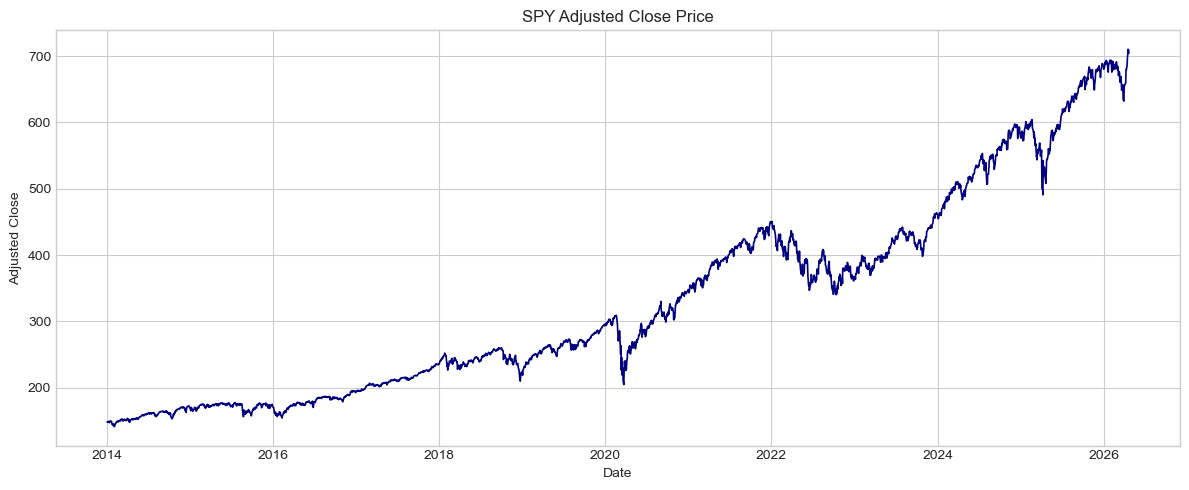

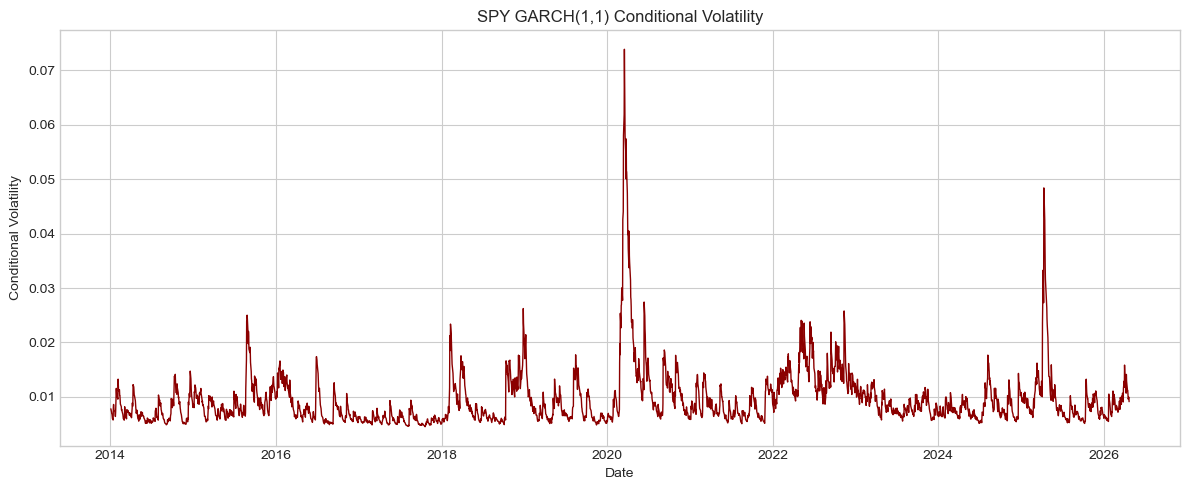

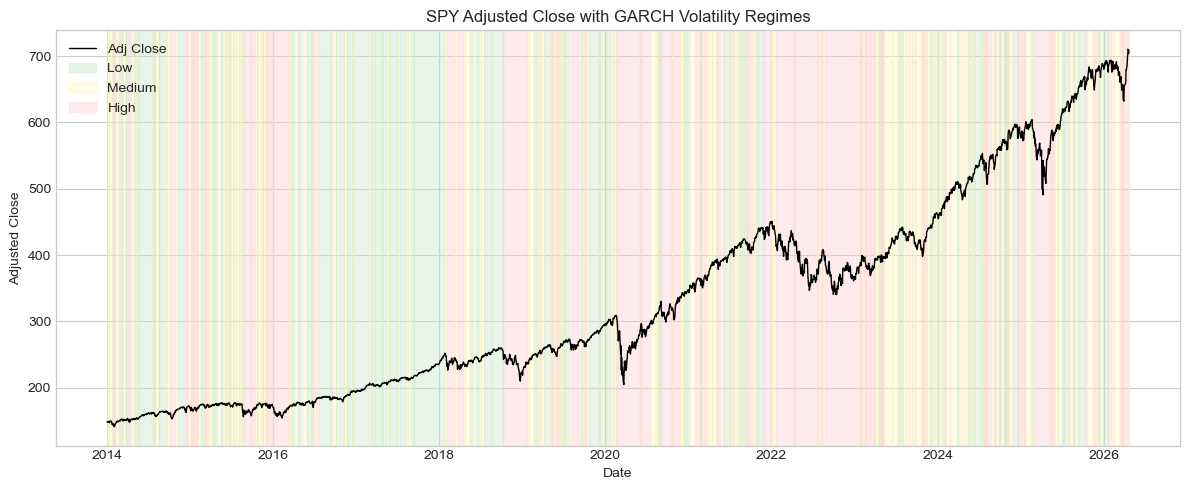

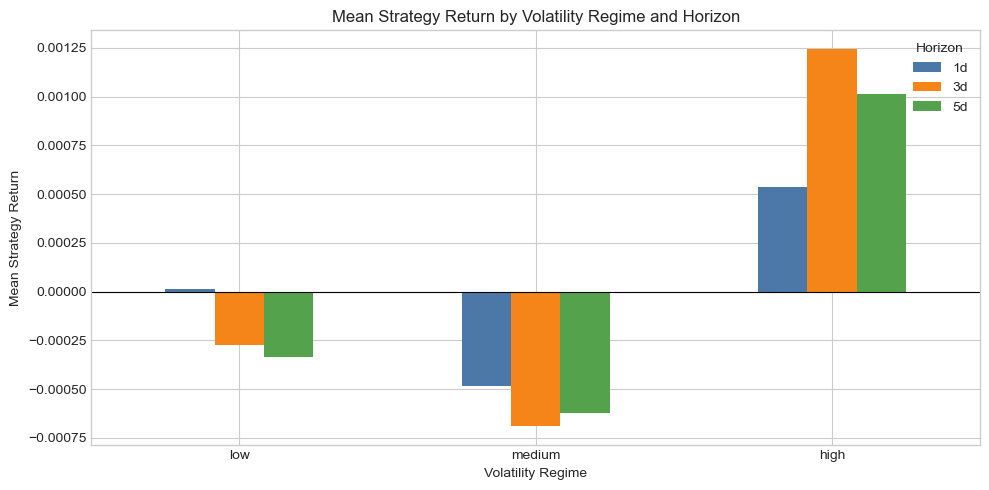

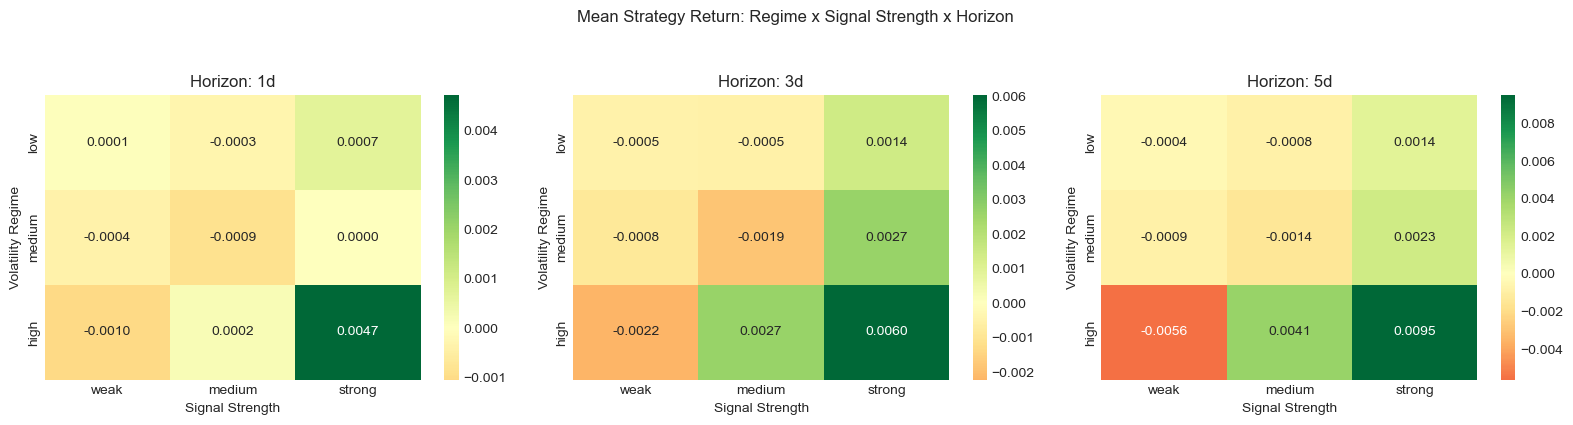

In [53]:
df = all_results['SPY'][0]

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['adj_close'], color='navy', linewidth=1.2)
plt.title('SPY Adjusted Close Price')
plt.xlabel('Date')
plt.ylabel('Adjusted Close')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'plot1_price_series.png'), dpi=150)  # Plot 1
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(df.index, df['cond_vol'], color='darkred', linewidth=1.0)
plt.title('SPY GARCH(1,1) Conditional Volatility')
plt.xlabel('Date')
plt.ylabel('Conditional Volatility')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'plot2_garch_volatility.png'), dpi=150)  # Plot 2
plt.show()

regime_colors = {'low': '#c8e6c9', 'medium': '#fff9c4', 'high': '#ffcdd2'}  # Plot 3 shading
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.index, df['adj_close'], color='black', linewidth=1.0, label='Adj Close')

current_regime = None
span_start = None
prev_date = None
for date, regime in df['vol_regime'].items():
    if pd.isna(regime):
        if current_regime is not None and span_start is not None and prev_date is not None:
            ax.axvspan(span_start, prev_date, color=regime_colors[str(current_regime)], alpha=0.4)
        current_regime = None
        span_start = None
        prev_date = date
        continue

    regime = str(regime)
    if current_regime is None:
        current_regime = regime
        span_start = date
    elif regime != current_regime:
        ax.axvspan(span_start, prev_date, color=regime_colors[current_regime], alpha=0.4)
        current_regime = regime
        span_start = date
    prev_date = date

if current_regime is not None and span_start is not None and prev_date is not None:
    ax.axvspan(span_start, prev_date, color=regime_colors[current_regime], alpha=0.4)

legend_patches = [mpatches.Patch(color=color, alpha=0.4, label=regime.title()) for regime, color in regime_colors.items()]
ax.legend(handles=[ax.lines[0]] + legend_patches, loc='best')
ax.set_title('SPY Adjusted Close with GARCH Volatility Regimes')
ax.set_xlabel('Date')
ax.set_ylabel('Adjusted Close')
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'plot3_regime_shading.png'), dpi=150)  # Plot 3
plt.show()

plot4_data = c2_table.pivot(index='vol_regime', columns='horizon', values='mean_return').reindex(['low', 'medium', 'high'])  # Plot 4
ax = plot4_data.plot(kind='bar', figsize=(10, 5), color=['#4c78a8', '#f58518', '#54a24b'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Mean Strategy Return by Volatility Regime and Horizon')
ax.set_xlabel('Volatility Regime')
ax.set_ylabel('Mean Strategy Return')
ax.legend(title='Horizon')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'plot4_returns_by_regime.png'), dpi=150)
plt.show()

heatmap_df = df.loc[df['signal'].ne(0)].copy()  # Plot 5 uses active signals only.
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(16, 4))
for ax, h in zip(np.atleast_1d(axes), HORIZONS):
    fwd_col = f'fwd_return_{h}d'
    heatmap_df[f'strategy_return_{h}d'] = heatmap_df['signal'] * heatmap_df[fwd_col]
    pivot = heatmap_df.dropna(subset=['vol_regime', 'signal_strength', f'strategy_return_{h}d']).pivot_table(
        index='vol_regime',
        columns='signal_strength',
        values=f'strategy_return_{h}d',
        aggfunc='mean',
        observed=True,
    )
    pivot = pivot.reindex(index=['low', 'medium', 'high'], columns=['weak', 'medium', 'strong'])
    sns.heatmap(pivot, annot=True, fmt='.4f', cmap='RdYlGn', center=0, ax=ax)
    ax.set_title(f'Horizon: {h}d')
    ax.set_xlabel('Signal Strength')
    ax.set_ylabel('Volatility Regime')

fig.suptitle('Mean Strategy Return: Regime x Signal Strength x Horizon', y=1.05)
plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'plot5_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

### Figure Captions

1. **SPY adjusted close:** shows the long-run price path used for the primary analysis.
2. **GARCH conditional volatility:** highlights volatility clustering in daily SPY returns.
3. **Price with volatility regimes:** overlays low, medium, and high GARCH volatility regimes on the price series.
4. **Returns by regime:** compares mean strategy returns across volatility regimes and forecast horizons.
5. **Regime x signal-strength heatmap:** shows where z-score mean-reversion signals are strongest or weakest.


In [54]:
c1_table.to_csv(os.path.join(TABLES_DIR, 'baseline_vs_high_vol_filtered.csv'), index=False)
c2_table.to_csv(os.path.join(TABLES_DIR, 'regime_comparison.csv'), index=False)
c3_table.to_csv(os.path.join(TABLES_DIR, 'signal_strength.csv'), index=False)
cross_asset_summary.to_csv(os.path.join(TABLES_DIR, 'cross_asset_high_vol_summary.csv'), index=True)

print(f'Saved tables to {TABLES_DIR}')
print('- baseline_vs_high_vol_filtered.csv')
print('- regime_comparison.csv')
print('- signal_strength.csv')
print('- cross_asset_high_vol_summary.csv')


Saved tables to /Users/tarun/workspace/recents/ic-project/outputs/tables
- baseline_vs_high_vol_filtered.csv
- regime_comparison.csv
- signal_strength.csv
- cross_asset_high_vol_summary.csv


### Paper-Backed Extension: Lehmann Reversal

The following extension adapts the short-horizon contrarian reversal idea from Lehmann (1990), which studies whether recent winner/loser portfolios exhibit return reversals inconsistent with a pure martingale benchmark. Here, the paper-style cross-sectional reversal portfolio is combined with the project's GARCH volatility-regime filter.

**Citation:** Lehmann, B. N. (1990). *Fads, Martingales, and Market Efficiency*. The Quarterly Journal of Economics, 105(1), 1-28.


=== Lehmann-Style Contrarian Reversal with Volatility Filtering ===
Dollar-neutral portfolio: long recent relative losers, short recent relative winners.
           strategy  lookback horizon  active_dates  positions  mean_return  median_return  std_return  hit_rate  sharpe_like
         lehmann_1d         1      1d          3090      15450     0.000154       0.000272    0.009645  0.513916     0.015937
         lehmann_1d         1      3d          3088      15440     0.000278       0.000080    0.016369  0.501619     0.017013
         lehmann_1d         1      5d          3086      15430     0.000303      -0.000126    0.020871  0.496760     0.014519
lehmann_1d_high_vol         1      1d          1290       4518     0.000204       0.000085    0.011551  0.505426     0.017699
lehmann_1d_high_vol         1      3d          1289       4516     0.000804       0.000256    0.019285  0.508146     0.041668
lehmann_1d_high_vol         1      5d          1287       4511     0.000743       0.000323

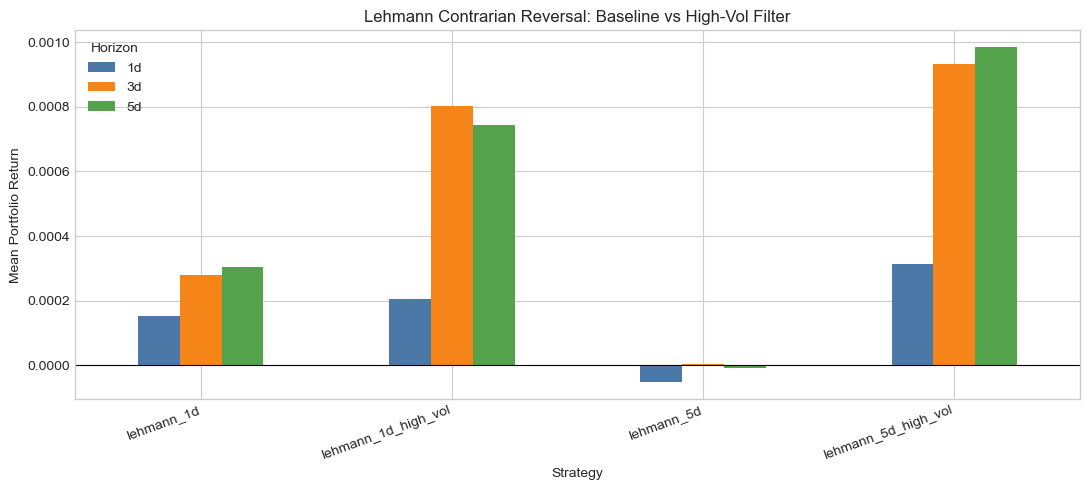

Saved: /Users/tarun/workspace/recents/ic-project/outputs/figures/plot6_lehmann_volatility_filter.png


In [55]:
# Lehmann-style contrarian reversal with GARCH volatility filtering
# Paper basis: Lehmann (1990), "Fads, Martingales, and Market Efficiency".
# Core rule: buy recent losers and short recent winners, then test whether returns reverse.
# This implementation uses dollar-neutral cross-sectional weights, which is closer to
# the paper's contrarian portfolio idea than a simple binary long/short signal.

def build_lehmann_reversal_panel(all_results, lookbacks=(1, 5), vol_filter_regime='high'):
    """Build paper-style Lehmann reversal portfolios with and without volatility filtering."""
    panel_parts = []

    # Reuse the processed DataFrames from the main pipeline so this extension keeps
    # the same adjusted-close data, GARCH regimes, and forward-return horizons.
    for ticker, result in all_results.items():
        if result is None:
            continue

        df_t, _ = result
        cols = ['adj_close', 'vol_regime'] + [f'fwd_return_{h}d' for h in HORIZONS]
        part = df_t[cols].copy()
        part['ticker'] = ticker

        # reset_index() may create either an 'index' column or a named column like 'Date'.
        # Rename the first column explicitly so cross-sectional ranking always has a
        # stable date field to group on.
        part = part.reset_index()
        part = part.rename(columns={part.columns[0]: 'date'})
        panel_parts.append(part)

    # A single panel lets us compare assets against each other on each date.
    # That cross-sectional comparison is the key change from the earlier SPY-only z-score test.
    panel = pd.concat(panel_parts, ignore_index=True).sort_values(['date', 'ticker'])
    rows = []

    def normalized_cross_sectional_weights(df, score_col):
        """Convert a contrarian score into daily dollar-neutral weights."""
        # Demeaning makes the portfolio dollar-neutral: positive weights fund negative weights.
        centered = df[score_col] - df.groupby('date')[score_col].transform('mean')

        # Gross exposure is normalized to 1.0 per active date for comparable returns.
        gross = centered.abs().groupby(df['date']).transform('sum')
        weights = centered.where(gross.gt(0)).div(gross.where(gross.gt(0))).fillna(0.0)
        return weights

    for lookback in lookbacks:
        temp = panel.copy()

        # Prior return is the Lehmann ranking variable.
        # Negative prior relative return means recent loser; positive means recent winner.
        temp['prior_return'] = temp.groupby('ticker')['adj_close'].pct_change(lookback)
        temp['prior_return_xs_mean'] = temp.groupby('date')['prior_return'].transform('mean')

        # Contrarian score flips prior relative performance:
        # recent losers receive positive scores, recent winners receive negative scores.
        temp['lehmann_score'] = -(temp['prior_return'] - temp['prior_return_xs_mean'])

        # Baseline Lehmann portfolio: use all assets in the current cross-section.
        base_weight_col = f'lehmann_{lookback}d_weight'
        temp[base_weight_col] = normalized_cross_sectional_weights(temp, 'lehmann_score')

        # Volatility-filtered portfolio: keep only assets currently in the high-vol regime,
        # then re-demean and renormalize within each date so the portfolio remains dollar-neutral.
        filtered_score_col = f'lehmann_{lookback}d_{vol_filter_regime}_vol_score'
        filtered_weight_col = f'lehmann_{lookback}d_{vol_filter_regime}_vol_weight'
        temp[filtered_score_col] = temp['lehmann_score'].where(temp['vol_regime'].eq(vol_filter_regime))
        temp[filtered_weight_col] = normalized_cross_sectional_weights(temp, filtered_score_col)

        for weight_col, strategy_name in [
            (base_weight_col, f'lehmann_{lookback}d'),
            (filtered_weight_col, f'lehmann_{lookback}d_{vol_filter_regime}_vol'),
        ]:
            for h in HORIZONS:
                fwd_col = f'fwd_return_{h}d'
                eval_df = temp.dropna(subset=[fwd_col]).copy()

                # Portfolio return is the daily sum of asset weight x forward return.
                # This is evaluated by date, not by individual signal, to match portfolio logic.
                eval_df['weighted_return'] = eval_df[weight_col] * eval_df[fwd_col]
                daily_returns = eval_df.groupby('date')['weighted_return'].sum()
                daily_gross = eval_df.groupby('date')[weight_col].apply(lambda x: x.abs().sum())
                active_returns = daily_returns.loc[daily_gross.gt(0)]

                std = active_returns.std()
                rows.append({
                    'strategy': strategy_name,
                    'lookback': lookback,
                    'horizon': f'{h}d',
                    'active_dates': int(active_returns.count()),
                    'positions': int(eval_df[weight_col].ne(0).sum()),
                    'mean_return': active_returns.mean(),
                    'median_return': active_returns.median(),
                    'std_return': std,
                    'hit_rate': active_returns.gt(0).mean(),
                    'sharpe_like': active_returns.mean() / std if std > 0 else np.nan,
                })

    return pd.DataFrame(rows)


lehmann_table = build_lehmann_reversal_panel(all_results)
lehmann_path = os.path.join(TABLES_DIR, 'lehmann_reversal_comparison.csv')
lehmann_table.to_csv(lehmann_path, index=False)

print('=== Lehmann-Style Contrarian Reversal with Volatility Filtering ===')
print('Dollar-neutral portfolio: long recent relative losers, short recent relative winners.')
print(lehmann_table.to_string(index=False))
print(f'Saved: {lehmann_path}')

# Plot 6: compare paper-style Lehmann reversal with its high-volatility-filtered version.
plot6_data = lehmann_table.pivot(index='strategy', columns='horizon', values='mean_return')
ax = plot6_data.plot(kind='bar', figsize=(11, 5), color=['#4c78a8', '#f58518', '#54a24b'])
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Lehmann Contrarian Reversal: Baseline vs High-Vol Filter')
ax.set_xlabel('Strategy')
ax.set_ylabel('Mean Portfolio Return')
ax.legend(title='Horizon')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
lehmann_plot_path = os.path.join(FIGURES_DIR, 'plot6_lehmann_volatility_filter.png')
plt.savefig(lehmann_plot_path, dpi=150)
plt.show()
print(f'Saved: {lehmann_plot_path}')

